# Regression

## Simple regression example

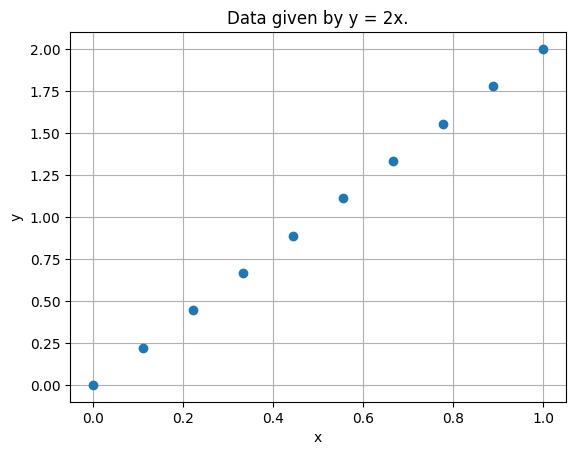

In [108]:
import numpy as np
import matplotlib.pyplot as plt

# Define arbitrarly x
x = np.linspace(0, 1, 10)
y = 2 * x

# Visualize the data
plt.plot(x, y, 'o')
plt.title("Data given by y = 2x.")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

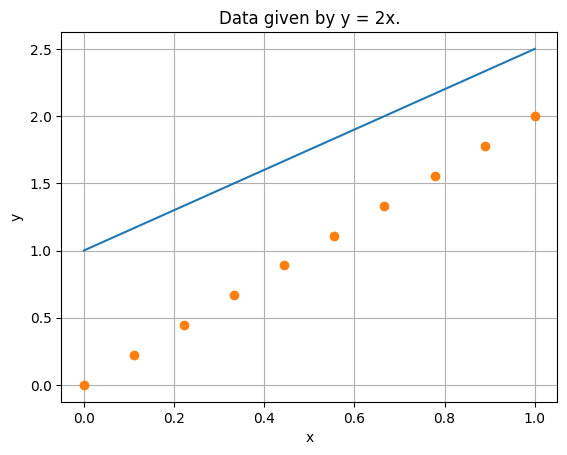

In [109]:
def f(x, theta):
    return theta[0] + theta[1]*x

# Visualize the data
theta = [1, 1.5]    # user defined
plt.plot(x, f(x, theta))    # NOTE: we want an algorithm that 
                            # approximate theta to the best 
                            # ([0,2] in this case)

plt.plot(x, y, 'o')
plt.title("Data given by y = 2x.")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

## Consider a more noisy example

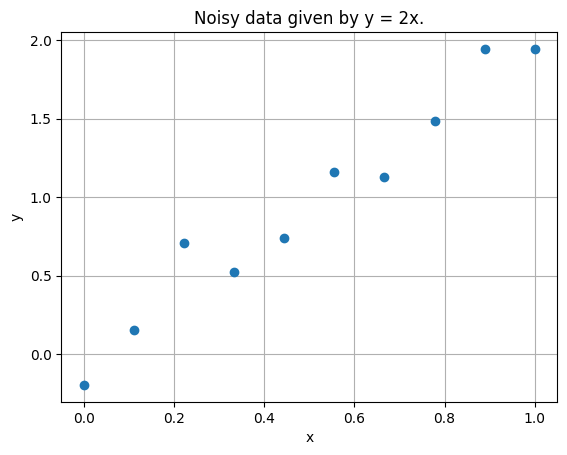

In [110]:
# Consider a little bit of noise
y_noisy = y + np.random.normal(loc=0, scale=0.2, size=y.shape)

# Visualize the noisy data
plt.plot(x, y_noisy, 'o')
plt.title("Noisy data given by y = 2x.")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

In [111]:
N = x.shape[0]

X = np.ones((2,N))
X[1] = x

Y = y_noisy     # if you set Y=y then you should obtain the true theta

In [112]:
# Step 1: Fattorizzazione di Cholesky
L = np.linalg.cholesky(X @ X.T)

# Step 2: Risoluzione del sistema triangolare inferiore Lz = b
z = np.linalg.solve(L, X @ Y)

# Step 3: Risoluzione del sistema triangolare superiore L^T theta = z
theta = np.linalg.solve(L.T, z)

In [113]:
theta

array([-0.07388051,  2.06616921])

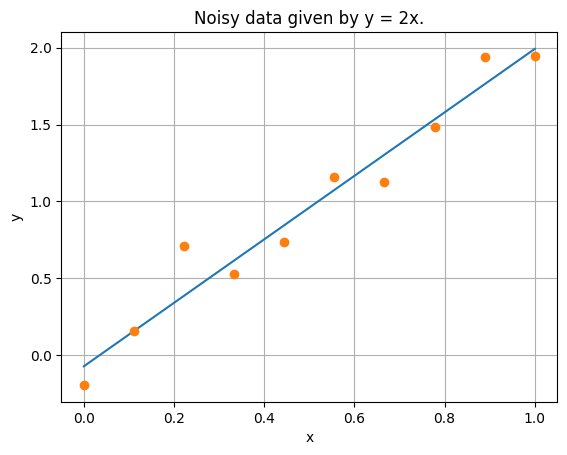

In [114]:
plt.plot(x, f(x, theta))

# Visualize the noisy data
plt.plot(x, y_noisy, 'o')
plt.title("Noisy data given by y = 2x.")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

## We use more complex data

In [115]:
import pandas as pd

small_df = pd.read_csv("./poly_regression_small.csv", index_col=0)

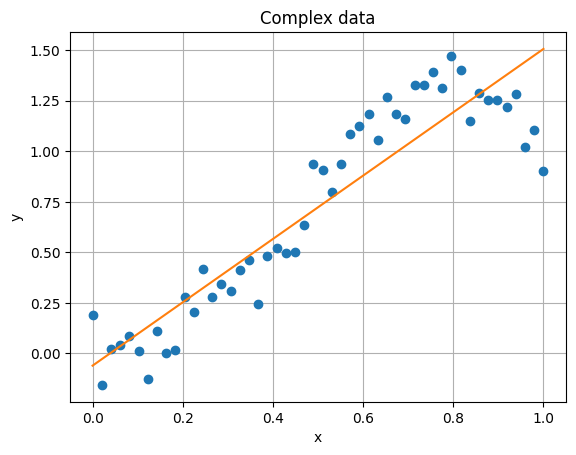

In [116]:
x, y = small_df["x"], small_df["y"]

# Create the linear system
N = x.shape[0]
X = np.ones((2,N))
X[1] = x
Y = y 

# Solve the system
L = np.linalg.cholesky(X @ X.T)
z = np.linalg.solve(L, X @ Y)
theta = np.linalg.solve(L.T, z)

# Visualize the data
plt.plot(x, y, 'o')
plt.plot(x, f(x, theta))
plt.title("Complex data")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

In [117]:
def vandermonde(x, K):
    N = x.shape[0]
    Phi = np.ones((K, N))
    for i in range(1, K):
        Phi[i, :] = x**i
    return Phi

In [118]:
def f_non_lin(x, theta):
    y = 0
    for j in range(len(theta)):
        y = y + theta[j] * x**j
    return y

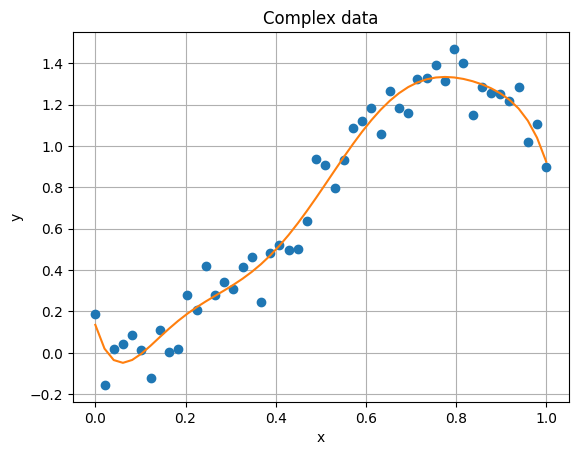

In [119]:
PhiX = vandermonde(x, K=8)    # Bigger K --> bigger overfit
Y = Y

# Solve the system
L = np.linalg.cholesky(PhiX @ PhiX.T)
z = np.linalg.solve(L, PhiX @ Y)
theta = np.linalg.solve(L.T, z)

# Visualize the data
plt.plot(x, y, 'o')
plt.plot(x, f_non_lin(x, theta))
plt.title("Complex data")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

## Exercise on the larger dataset

In [121]:
large_df = pd.read_csv("./poly_regression_large.csv", index_col=0)
x, y = large_df["x"], large_df["y"]

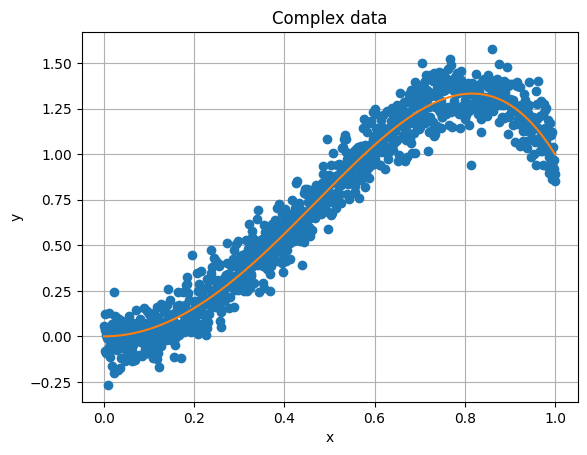

In [135]:
PhiX = vandermonde(x, K=8)    
Y = Y

# Solve the system
L = np.linalg.cholesky(PhiX @ PhiX.T)
z = np.linalg.solve(L, PhiX @ Y)
theta = np.linalg.solve(L.T, z)
theta_true = [0, 0, 4, 0, -3]

# Visualize the data
plt.plot(x, y, 'o')
# plt.plot(x, f_non_lin(x, theta))

# Chose one of those 2 approaches
plt.plot(x, f_non_lin(x, theta_true))
# plt.plot(x, (4*x**2-3*x**4))

plt.title("Complex data")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

# SGD (Stochastic Gradient Descent)

- You can't use backtracking and stopping criteria

In [ ]:
import numpy as np

def SGD(loss, grad_loss, D, theta0, alpha, batch_size, n_epochs):
    X, y = D  # Unpack the data
    N = X.shape[0] # We assume both X and Y has shape (N, )
    d = theta0.shape[0] # While theta0 has shape (d, )
    idx = np.arange(0, N) # This is required for the shuffling
    
    # Initialization of history vectors
    theta_history = np.zeros((n_epochs, d))  # Save parameters at each epoch
    loss_history = np.zeros((n_epochs, ))  # Save loss values at each epoch
    grad_norm_history = np.zeros((n_epochs, ))  # Save gradient norms at each epoch
    
    # Initialize weights
    theta = theta0
    for epoch in range(n_epochs):
        # Shuffle the data at the beginning of each epoch
        np.random.shuffle(idx)
        X = X[idx]
        y = y[idx]

        # Initialize a vector that saves the gradient of the loss at each iteration
        grad_loss_vec = []

        for batch_start in range(0, N, batch_size):
            batch_end = min(batch_start + batch_size, N)
            X_batch = X[batch_start:batch_end]
            y_batch = y[batch_start:batch_end]
            
            # Compute the gradient of the loss
            gradient = grad_loss(theta, X_batch, y_batch)
            grad_loss_vec.append(np.linalg.norm(gradient, 2))

            # Update weights
            theta = theta - alpha * gradient

        # Save the updated values
        theta_history[epoch] = theta
        loss_history[epoch] = loss(theta, X, y)
        grad_norm_history[epoch] = np.mean(grad_loss_vec)
    
    return theta_history, loss_history, grad_norm_history

In [ ]:
def f(x, theta):
    y = 0
    for j in range(len(theta)):
        y = y + theta[j] * x**j
    return y

In [ ]:
def loss(theta, X, y):
    y_pred = f(X, theta)
    error = np.square(y_pred - y)
    return np.mean(error)

In [ ]:
def grad_loss(theta, X, y):
    return "il goat"